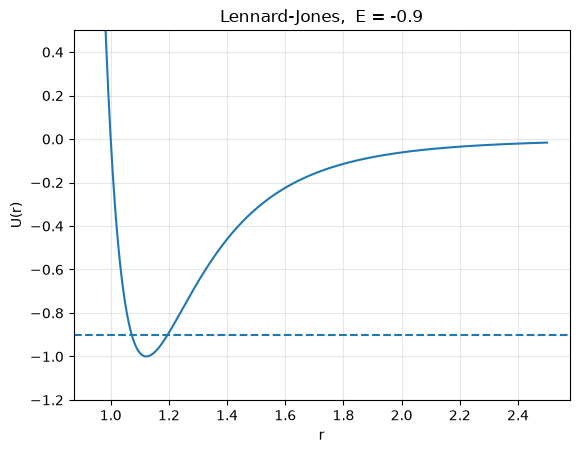

In [1]:
import numpy as np, matplotlib.pyplot as plt
from scipy.optimize import brentq

eps = sig = mu = 1.0
U    = lambda r: 4*eps*((sig/r)**12 - (sig/r)**6)
d2U  = lambda r: 4*eps*(156*sig**12/r**14 - 42*sig**6/r**8)

r = np.linspace(0.95, 2.5, 600)
E = -0.90                                  # pick a bound energy
plt.plot(r, U(r)); plt.axhline(E, ls='--')
plt.ylim(-1.2, 0.5); plt.xlabel('r'); plt.ylabel('U(r)')
plt.title(f'Lennard-Jones,  E = {E}'); plt.grid(alpha=.3); plt.show()

In [2]:
r_min = 2**(1/6)*sig
r1 = brentq(lambda r: U(r) - E, 0.5*sig, r_min)     # inner root
r2 = brentq(lambda r: U(r) - E, r_min, 50*sig)      # outer root
print(f"r1 = {r1:.6f}   r2 = {r2:.6f}")           

r1 = 1.072218   r2 = 1.195877


In [3]:
def T_naive(E, N):
    r1 = brentq(lambda r: U(r)-E, 0.5, r_min)
    r2 = brentq(lambda r: U(r)-E, r_min, 50.0)
    h  = (r2 - r1)/N
    r  = r1 + h*(np.arange(N) + 0.5)          # midpoints: avoids r1, r2 exactly
    f  = 1.0/np.sqrt((2/mu)*(E - U(r)))
    return 2*h*np.sum(f)

print(T_naive(-0.90, 100)) 

0.8540954255546653


In [4]:
values = {}   # store T(N) so we don’t recompute unnecessarily
diff_half = {}  # store diff_half(N) so we can access diff_half(N-1)

for N in [100, 200, 400, 800, 1600, 3200]:
    # compute and store T(N)
    values[N] = T_naive(-0.90, N)

    # compute diff_half(N)
    if N == 100:
        diff_half[N] = None
    else:
        diff_half[N] = values[N] - values[N//2]

    # build output line
    line = f"N={N:5d}   T={values[N]:.7f}"

    # print diff_half if available
    if diff_half[N] is not None:
        line += f"   diff_half={diff_half[N]:.3e}"

    # print ratio only if N > 200
    if N > 200:
        prev = N//2   # the previous halving step
        if diff_half[prev] is not None and diff_half[prev] != 0:
            ratio = diff_half[N] / diff_half[prev]
            line += f"   ratio={ratio:.3e}"

    print(line)

N=  100   T=0.8540954
N=  200   T=0.8641489   diff_half=1.005e-02
N=  400   T=0.8712614   diff_half=7.113e-03   ratio=7.075e-01
N=  800   T=0.8762920   diff_half=5.031e-03   ratio=7.073e-01
N= 1600   T=0.8798497   diff_half=3.558e-03   ratio=7.072e-01
N= 3200   T=0.8823655   diff_half=2.516e-03   ratio=7.072e-01


In [5]:
def T_sub(E, N):
    r1 = brentq(lambda r: U(r)-E, 0.5, r_min)
    r2 = brentq(lambda r: U(r)-E, r_min, 50.0)
    c, a = 0.5*(r1+r2), 0.5*(r2-r1)
    th = -np.pi/2 + np.pi*(np.arange(N) + 0.5)/N
    r  = c + a*np.sin(th)
    f  = a*np.cos(th)/np.sqrt((2/mu)*(E - U(r)))   # cos cancels the 1/sqrt
    return 2*(np.pi/N)*np.sum(f)

for N in [100, 400, 1600, 6400]:
    print(N, f"{T_sub(-0.90, N):.7f}")   # 0.8884395 at every N — already converged

100 0.8884395
400 0.8884395
1600 0.8884395
6400 0.8884395


In [6]:
from scipy.integrate import quad
f = lambda r: 1.0/np.sqrt((2/mu)*(-0.90 - U(r)))
val, err = quad(f, r1, r2, limit=200)
print(2*val, 2*err)        # 0.8884395   est. err 1.4e-10

0.888439503769421 1.432889362718015e-10


In [7]:
T_harm = 2*np.pi/np.sqrt(d2U(r_min)/mu)          # 0.831161
for E in [-0.9, -0.99, -0.999, -0.9999, -0.99999]:
    print(f"E={E:9.5f}  T={T_sub(E,20000):.6f}  T/T_harm={T_sub(E,20000)/T_harm:.6f}")

E= -0.90000  T=0.888440  T/T_harm=1.068914
E= -0.99000  T=0.836457  T/T_harm=1.006372
E= -0.99900  T=0.831687  T/T_harm=1.000632
E= -0.99990  T=0.831214  T/T_harm=1.000063
E= -0.99999  T=0.831163  T/T_harm=1.000002
